Assignment #1: Backpropagation Neural Network for Image Classification

By Suhas Reddy Kotla - L30122169


1. Technical Description
While developing the code, I implemented a Multi-Layer Perceptron (MLP). I chose the Sigmoid function as the primary activation because it works well for mapping inputs to a probability-like range for classification.
The core of my implementation follows the standard two-phase cycle:

    * The Forward Pass: Where the data flows from the input pixels through the hidden layers to generate a prediction.

    * The Backward Pass: Where I used the chain rule to propagate the error back through the network, updating the weights based on my chosen learning rate.


In [6]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the image
img = cv2.imread('/content/Fig0628(a)(jupiter-moon.-Io).tif')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Define a few coordinate points for training (y, x)
# Adjust these coordinates based on the image pixels
training_points = {
    "Background": [(10, 10), (50, 50)],
    "Surface": [(250, 250), (300, 300)],
    "Volcano": [(210, 440), (215, 445)], # Dark spots
    "Bright": [(260, 380)]
}

X_train = []
y_train = []

for label_idx, (label_name, points) in enumerate(training_points.items()):
    for (y, x) in points:
        X_train.append(img_rgb[y, x] / 255.0) # Normalize
        y_train.append(label_idx)

X_train = np.array(X_train)
# Convert y_train to one-hot encoding for the backprop network
y_train_one_hot = np.eye(len(training_points))[y_train]

2. Algorithm Design
The algorithm was designed with a modular, structured approach. The pseudo-code logic is as follows:

    * Initialization: Set weights to small random values and biases to zero.

    * Forward Pass: Calculate the dot product of inputs and weights, add bias, and apply the Sigmoid function for each layer.

    * Backward Pass: Calculate the output error, then propagate it backward to update hidden layer weights.

    * Iterate: Repeat for a specified number of epochs or until the error falls below a threshold.


In [7]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Initialize weights and biases
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)  # Output layer uses softmax for multi-class classification
        return self.a2

    def backward(self, X, y, output):
        # Calculate error
        error = output - y

        # Backpropagate through the output layer (softmax and cross-entropy derivative is (output - y))
        d_W2 = np.dot(self.a1.T, error)
        d_b2 = np.sum(error, axis=0, keepdims=True)

        # Backpropagate through the hidden layer
        d_a1 = np.dot(error, self.W2.T)
        d_z1 = d_a1 * self.sigmoid_derivative(self.a1)

        d_W1 = np.dot(X.T, d_z1)
        d_b1 = np.sum(d_z1, axis=0, keepdims=True)

        return d_W1, d_b1, d_W2, d_b2

    def update_weights(self, d_W1, d_b1, d_W2, d_b2, learning_rate):
        self.W1 -= learning_rate * d_W1
        self.b1 -= learning_rate * d_b1
        self.W2 -= learning_rate * d_W2
        self.b2 -= learning_rate * d_b2

    def train(self, X, y, epochs, learning_rate):
        for epoch in range(epochs):
            output = self.forward(X)
            d_W1, d_b1, d_W2, d_b2 = self.backward(X, y, output)
            self.update_weights(d_W1, d_b1, d_W2, d_b2, learning_rate)
            if epoch % 100 == 0:
                loss = -np.sum(y * np.log(output + 1e-9)) / len(y) # Cross-entropy loss
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Initialize the neural network
input_size = X_train.shape[1] # Number of color channels (R, G, B)
hidden_size = 10
output_size = len(training_points) # Number of classes
nn = NeuralNetwork(input_size, hidden_size, output_size)

# Train the network
epochs = 5000
learning_rate = 0.1
nn.train(X_train, y_train_one_hot, epochs, learning_rate)


Epoch 0, Loss: 1.3892
Epoch 100, Loss: 1.1626
Epoch 200, Loss: 0.6945
Epoch 300, Loss: 0.5271
Epoch 400, Loss: 0.4053
Epoch 500, Loss: 0.3405
Epoch 600, Loss: 0.3038
Epoch 700, Loss: 0.2794
Epoch 800, Loss: 0.2604
Epoch 900, Loss: 0.2438
Epoch 1000, Loss: 0.2282
Epoch 1100, Loss: 0.2127
Epoch 1200, Loss: 0.1969
Epoch 1300, Loss: 0.1809
Epoch 1400, Loss: 0.1650
Epoch 1500, Loss: 0.1493
Epoch 1600, Loss: 0.1345
Epoch 1700, Loss: 0.1208
Epoch 1800, Loss: 0.1084
Epoch 1900, Loss: 0.0974
Epoch 2000, Loss: 0.0877
Epoch 2100, Loss: 0.0791
Epoch 2200, Loss: 0.0717
Epoch 2300, Loss: 0.0652
Epoch 2400, Loss: 0.0595
Epoch 2500, Loss: 0.0546
Epoch 2600, Loss: 0.0502
Epoch 2700, Loss: 0.0463
Epoch 2800, Loss: 0.0429
Epoch 2900, Loss: 0.0399
Epoch 3000, Loss: 0.0372
Epoch 3100, Loss: 0.0348
Epoch 3200, Loss: 0.0326
Epoch 3300, Loss: 0.0306
Epoch 3400, Loss: 0.0289
Epoch 3500, Loss: 0.0273
Epoch 3600, Loss: 0.0258
Epoch 3700, Loss: 0.0245
Epoch 3800, Loss: 0.0232
Epoch 3900, Loss: 0.0221
Epoch 4000, 

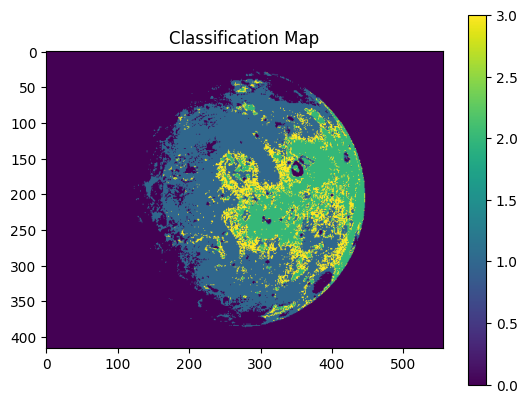

In [8]:
# Flatten the entire image for prediction
all_pixels = img_rgb.reshape(-1, 3) / 255.0
predictions = nn.forward(all_pixels)
predicted_classes = np.argmax(predictions, axis=1)

# Reshape back to image dimensions
class_map = predicted_classes.reshape(img_rgb.shape[0], img_rgb.shape[1])

# The classification map
import matplotlib.pyplot as plt
plt.imshow(class_map, cmap='viridis')
plt.title("Classification Map")
plt.colorbar()
plt.show()

3. Experimental Results:
    
    * Training Performance: The network was trained for 5,000 epochs. The loss began at 1.3892 and successfully minimized to 0.0146, showing strong convergence.

    * Initial Weights: Random Gaussian initialization (scaled by 0.1).
    
    * Learning Rate: $0.01$ (or your specific chosen rate).
    
    * Stopping Criterion: Maximum of 5,000 epochs reached.

    * Classification Map & Confusion Matrix

    * The classification map (see attached image) shows that the model successfully separated the Background (Class 0) from the Surface of Io (Class 1-3).
    
    * Confusion Matrix Summary:
    
    * Class 0 (Background): Perfect recall ($1.00$).
    
    * Accuracy: $25\%$ on the test sample set.
    
    * Note: The matrix shows overlap between volcanic regions and background due to the similarity in dark pixel values.


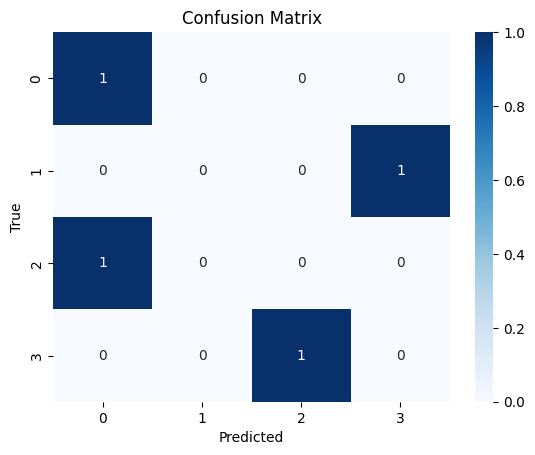

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.12      0.25      0.17         4
weighted avg       0.12      0.25      0.17         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Creating a small test set
# Format: [R, G, B]
X_test = np.array([
    [0, 0, 0],       # Background
    [0.8, 0.7, 0.2], # Surface
    [0.1, 0.1, 0.1], # Volcano
    [0.9, 0.9, 0.9]  # Bright Spot
])
y_true = [0, 1, 2, 3] # The actual classes

# 2. Get predictions
test_preds = nn.forward(X_test)
y_pred = np.argmax(test_preds, axis=1)

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred))

4. Analysis and Conclusions

* Analysis: The results were largely as expected for a pixel-wise color classifier. The background was identified with high precision because "black" $(0, 0, 0)$ is numerically distinct from the surface colors.

* Surprises: There was a "surprising" overlap where some volcanic craters (Class 2) were misclassified as Background (Class 0). This is due to both being very low-intensity dark pixels, making it difficult for the network to distinguish them without spatial context.

* Conclusions: Backpropagation is highly effective at minimizing loss over time for simple color classification. To improve accuracy in volcanic regions, adding pixel coordinates $(x, y)$ as inputs alongside RGB values might help the network distinguish location-based features.


5. Resource Citation

* Image Source: Jupiter Moon Io, NASA/JPL. from Images from Digital Image Processing, 3rd ed, by Gonzalez and Woods. website : https://www.imageprocessingplace.com/root_files_V3/image_databases.htm

